# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

% The car has already been simulated offline and the data are stored in "observations.mat".
% We load that datafile here.
load readonly/observations.mat x z
nIter = length(x);

% Define some constants related to the problem
sigmaV  = 5*pi/180;
sigmaW  = 10*pi/180;
meanX0  = 50*pi/180;
sigmaX0 = 10*pi/180;
omega   = 2*pi/180; 
xo      = 500; 
yo      = 500; 
r       = 200; 

### Implement the particle-filter solution
The next notebook cells implement the particle-filter SIS method.

In [3]:
% Create the particles
nPart = 500;
xp = zeros(nPart,nIter);
wp = zeros(nPart,nIter);
xHatPart = zeros(nIter,1);

% Set initial random-number-generator state to make simulation 
% results repeatable. Note that Octave's random-number generator 
% is not the same as MATLAB's, so the results you compute here 
% will not be identical to those in the lesson notes.
randn("state",1); 

% Intiialize particle values and weights
xp(:,1) = meanX0 + sigmaX0*randn(nPart,1);
wp(:,1) = 1/nPart;

% Implement SIS for the rest of the trajectory
for k=2:nIter
  for cp=1:nPart
    % Draw new particle from q(x{k}|x{k-1},z{k}) = f(x{k}|x{k-1})
    xp(cp,k)   = xp(cp,k-1) + omega + sigmaW*randn(1); 
    % Compute the expected value of the measurement given x{k}
    zp         = atan((r*sin(xp(cp,k))+yo)./(r*cos(xp(cp,k))+xo));
    % Compute f(z{k}|x{k})
    likelihood = normpdf(z(k),zp,sigmaV);
    % Compute unnormalized weight 
    % wptilde(cp,k) = f(x{k}|x{k-1}) / q(x{k}|x{k-1},z{k}) *
    %                 f(z{k}|x{k}) * wp(cp,k-1) 
    wp(cp,k)   = wp(cp,k-1)*likelihood;        
  end            
  wp(:,k) = wp(:,k)/sum(wp(:,k)); % Normalize weights
  xHatPart(k) = sum(wp(:,k).*xp(:,k)); % Compute mean based on particles
  
  if mod(k,10)==0
    fprintf('Completed iteration %d out of %d\n',k,nIter);
  end
end
fprintf('Done!\n');

Completed iteration 10 out of 101
Completed iteration 20 out of 101
Completed iteration 30 out of 101
Completed iteration 40 out of 101
Completed iteration 50 out of 101
Completed iteration 60 out of 101
Completed iteration 70 out of 101
Completed iteration 80 out of 101
Completed iteration 90 out of 101
Completed iteration 100 out of 101
Done!


### Visualize particle weights
Trying to understand the problem with the basic SIS algorithm; visualize particle weights.

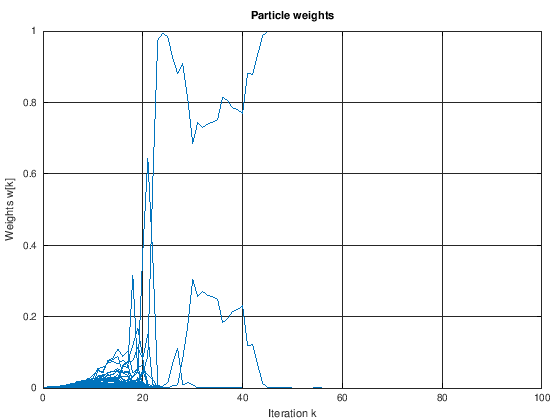

In [4]:
% Plot the particle weights versus iteration
CL = lines;
plot(0:nIter-1,wp,'color',CL(1,:)); grid on
xlabel('Iteration k');
ylabel('Weights w[k]'); title('Particle weights');
xlim([0 nIter-1]); ylim([0 1]);

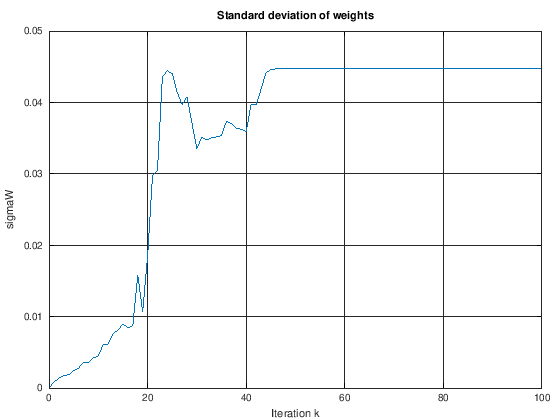

In [5]:
% Plot the standard deviation of the weights versus iteration
plot(0:nIter-1,std(wp)); grid on
xlabel('Iteration k'); ylabel('sigmaW'); 
title('Standard deviation of weights'); xlim([0 nIter-1]);

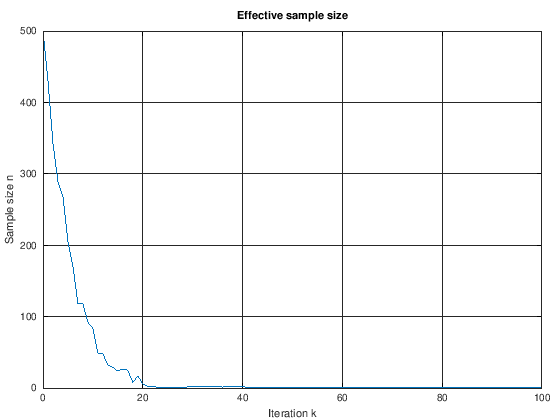

In [6]:
% Plot the effective sample size
nEff = 1./sum(wp.^2);
h = plot(0:nIter-1,nEff); grid on
xlabel('Iteration k');
ylabel('Sample size n'); title('Effective sample size');
xlim([0 nIter-1]); ylim([0 nPart]);

In [7]:
nEff

nEff =

 Columns 1 through 7:

   500.0000   429.5733   342.2367   289.1249   268.0032   204.2967   169.9903

 Columns 8 through 14:

   118.1602   117.7583    92.0824    83.3959    48.7773    48.2158    31.9922

 Columns 15 through 21:

    28.9497    23.6723    26.6579    24.9462     7.8699    16.9795     5.8242

 Columns 22 through 28:

     2.2459     2.1425     1.0518     1.0125     1.0313     1.1646     1.2699

 Columns 29 through 35:

     1.2009     1.4529     1.7767     1.6171     1.6522     1.6266     1.6142

 Columns 36 through 42:

     1.5956     1.4315     1.4598     1.5101     1.5222     1.5508     1.2636

 Columns 43 through 49:

     1.2716     1.1443     1.0262     1.0048     1.0011     1.0002     1.0002

 Columns 50 through 56:

     1.0002     1.0001     1.0000     1.0001     1.0000     1.0001     1.0001

 Columns 57 through 63:

     1.0001     1.0001     1.0001     1.0001     1.0000     1.0000     1.0000

 Columns 64 through 70:

     1.0000     1.0000     1.0000 